<a href="https://colab.research.google.com/github/Sydney205/lagos-hydrological-risk-pipeline/blob/syd-205/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from huggingface_hub import hf_hub_download
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = hf_hub_download(
    repo_id="Sydney205/lagos-hydrological-zone-data",
    filename="master_lagos_hydrological_zone_with_flood_features.csv",
    repo_type="dataset",
)

df = pd.read_csv(file_path)

master_lagos_hydrological_zone_with_floo(…): reconstructing file:   0%|          |  0.00B / 30.0MB            

master_lagos_hydrological_zone_with_floo(…): downloading bytes:           |  0.00B            

In [4]:
df.head()

,weather_code,State,LGA_Location,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,precipitation_sum,...,shortwave_radiation_sum,et0_fao_evapotranspiration,Date,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,river_discharge
0,53,Ogun,Abeokuta North,31.7,25.3,27.4,36.8,30.2,32.0,1.4,...,19.03,4.11,2012-05-01,0.402125,0.364042,0.274000,28.366667,28.366667,28.400000,0.63
1,63,Ogun,Abeokuta North,30.9,24.1,26.6,35.4,29.0,31.3,5.4,...,16.06,3.46,2012-05-02,0.408458,0.363750,0.274750,27.650000,28.062500,28.400000,1.09
2,63,Ogun,Abeokuta North,30.4,24.1,26.2,36.1,28.8,30.6,7.2,...,14.66,3.17,2012-05-03,0.434083,0.374542,0.275000,27.287500,27.700000,28.316667,1.31
3,61,Ogun,Abeokuta North,31.5,24.5,26.9,37.6,29.0,31.4,3.2,...,18.88,4.06,2012-05-04,0.427083,0.386167,0.275875,27.758333,27.683333,28.245833,0.97
4,51,Ogun,Abeokuta North,33.1,23.2,27.4,38.7,27.6,32.1,0.1,...,22.88,4.96,2012-05-05,0.407167,0.385500,0.276667,28.258333,27.991667,28.200000,0.41


In [13]:
df['LGA_Location'].unique().tolist()

['Abeokuta North',
 'Abeokuta South',
 'Ado-Odo Ota',
 'Agege',
 'Ajeromi-Ifelodun',
 'Alimosho',
 'Amuwo-Odofin',
 'Apapa',
 'Badagry',
 'Epe',
 'Eti-Osa',
 'Ibadan Southwest',
 'Ibeju-Lekki',
 'Ifako-Ijaiye',
 'Ifo',
 'Ijebu Ode',
 'Ikeja',
 'Ikorodu',
 'Kosofe',
 'Lagos Island',
 'Lagos Mainland',
 'Mushin',
 'Obafemi Owode',
 'Odeda',
 'Ojo',
 'Ondo West',
 'Oshodi-Isolo',
 'Sagamu',
 'Somolu',
 'Surulere']

In [5]:
keep_cols = [
    "Date",
    "State",
    "LGA_Location",
    "precipitation_sum",
    "rain_sum",
    "precipitation_hours",
    "river_discharge",
    "soil_moisture_0_to_7cm",
    "soil_moisture_7_to_28cm",
    "et0_fao_evapotranspiration",
    "weather_code",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
]

df_clean = df[keep_cols].copy()

In [6]:
num_data = df_clean.select_dtypes(include="number")
cat_data = df_clean.select_dtypes(exclude="number")

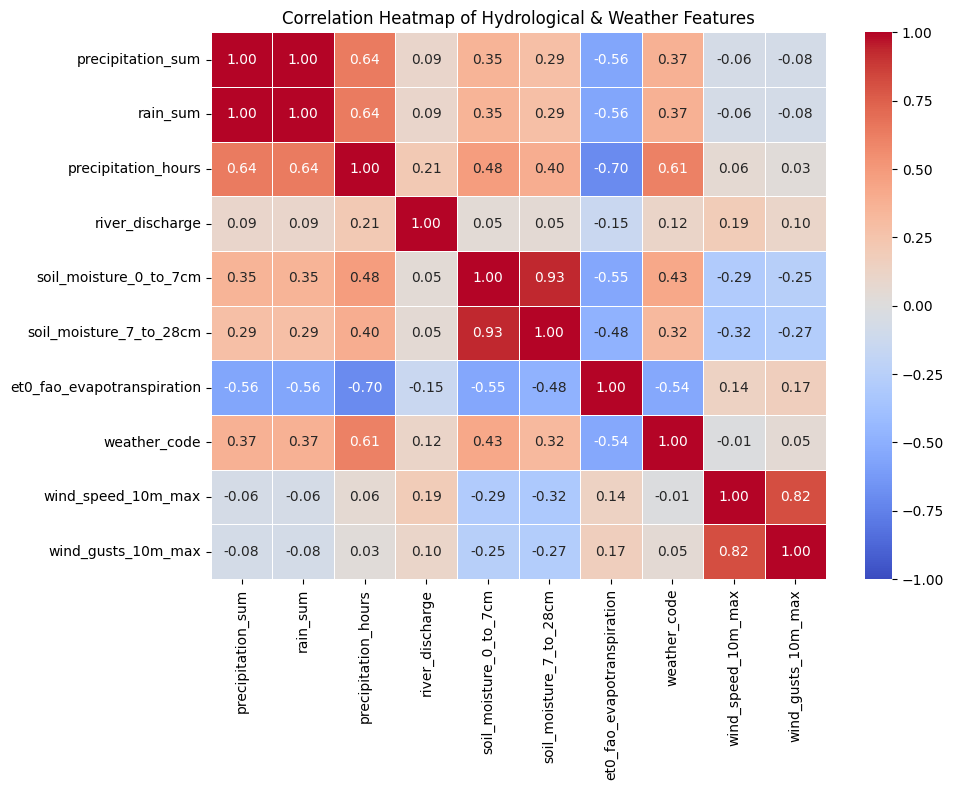

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = num_data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Hydrological & Weather Features")
plt.tight_layout()
plt.show()

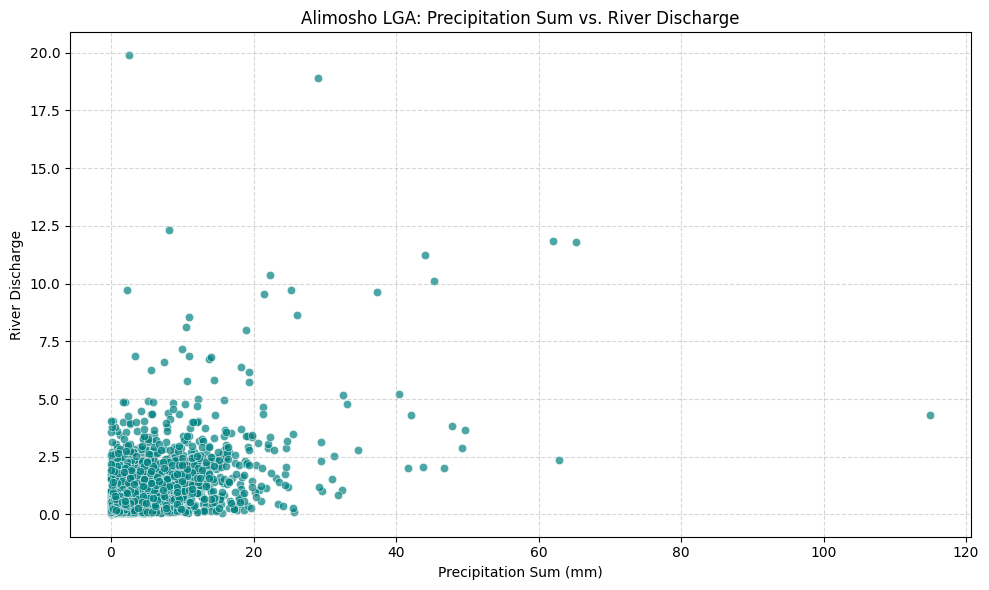

In [16]:

# Filter the dataframe for Alimosho LGA
alimosho_df = df_clean[df_clean['LGA_Location'] == 'Abeokuta North']

# Create a scatter plot of precipitation_sum vs river_discharge for Alimosho
plt.figure(figsize=(10, 6))
sns.scatterplot(data=alimosho_df, x='precipitation_sum', y='river_discharge', alpha=0.7, color='teal')

plt.title('Alimosho LGA: Precipitation Sum vs. River Discharge')
plt.xlabel('Precipitation Sum (mm)')
plt.ylabel('River Discharge')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()